In [10]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [11]:
# descarga de datos
df_apple = yf.download('AAPl', period='5y', interval='1d')

# limpieza
df_apple.columns = df_apple.columns.get_level_values(0)
df_apple.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


In [12]:
# columna de retorno
df_apple['Return'] = df_apple['Close'].pct_change() * 100
df_apple.dropna(inplace=True)

# curtuosis, sesgo, desviacion estandar
std_dev = df_apple['Return'].std()
skew = df_apple['Return'].skew()
kurt = df_apple['Return'].kurt()

# percentiles
p25 = df_apple['Return'].quantile(0.25)
p75 = df_apple['Return'].quantile(0.75)

# transformar index a fechas y generar estadisticas por fechas
df_apple.index = pd.to_datetime(df_apple.index)
semestral_stats = df_apple.groupby(pd.Grouper(freq='6ME'))['Return'].agg(['std', 'kurt', 'skew', 'mean'])
yearly_stats = df_apple.groupby(df_apple.index.year)['Return'].agg(['std', 'kurt', 'skew', 'mean'])

# impresion
print('5 years stats')
print(f'std:    {std_dev: .3f}%')
print(f'skew:   {skew: .3f}%')
print(f'kurt:   {kurt: .3f}%')
print(f'p25:    {p25: .3f}%')
print(f'p75:    {p75: .3f}%')

print('\nYearly stats')
print(yearly_stats)

print('\nSemestral stats')
print(semestral_stats)

5 years stats
std:     1.732%
skew:    0.461%
kurt:    6.956%
p25:    -0.770%
p75:     0.955%

Yearly stats
           std       kurt      skew      mean
Date                                         
2021  1.375231   0.297562 -0.213852  0.170927
2022  2.248664   1.053225  0.316406 -0.096961
2023  1.278789   1.479386 -0.068730  0.167797
2024  1.428735   3.615544  0.446117  0.116434
2025  2.048012  14.083538  1.131014  0.055293
2026  1.587147   1.003708 -0.105152  0.021141

Semestral stats
                 std       kurt      skew      mean
Date                                               
2021-04-30  0.641783   1.586062 -1.359350 -0.608966
2021-10-31  1.280337   0.186618 -0.362746  0.113553
2022-04-30  1.876010   0.529266  0.380414  0.060429
2022-10-31  2.352274   0.321631 -0.159909  0.007959
2023-04-30  1.887309   3.293076  0.672754  0.102463
2023-10-31  1.231036   2.739429 -0.349762  0.014678
2024-04-30  1.254125   1.557611  0.055009  0.007808
2024-10-31  1.572504   4.047688  0.6070

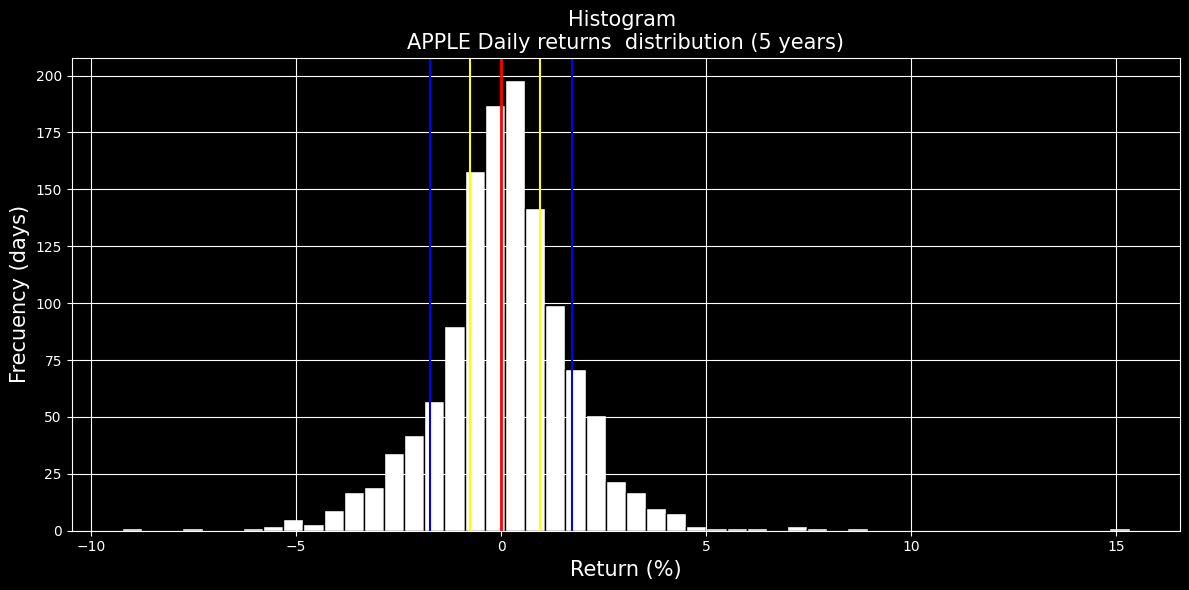

In [13]:
# histograma
plt.figure(figsize=(12, 6))
plt.hist(df_apple['Return'], bins=50, color='white', edgecolor='black')
plt.style.use('dark_background')

plt.axvline(0, color='red', linestyle='-', linewidth=2) # linea visual para el 0
plt.axvline(std_dev, color='blue', linestyle='-', linewidth=1.5) # std
plt.axvline(-std_dev, color='blue', linestyle='-', linewidth=1.5) # -std
plt.axvline(p25, color='yellow', linestyle='-', linewidth=1.5) # percentil 25
plt.axvline(p75, color='yellow', linestyle='-', linewidth=1.5) # percentile 75

plt.title('Histogram \nAPPLE Daily returns  distribution (5 years)', fontsize=15)
plt.xlabel('Return (%)', fontsize=15)
plt.ylabel('Frecuency (days)', fontsize=15)
plt.tight_layout()
plt.grid(True)
plt.show()

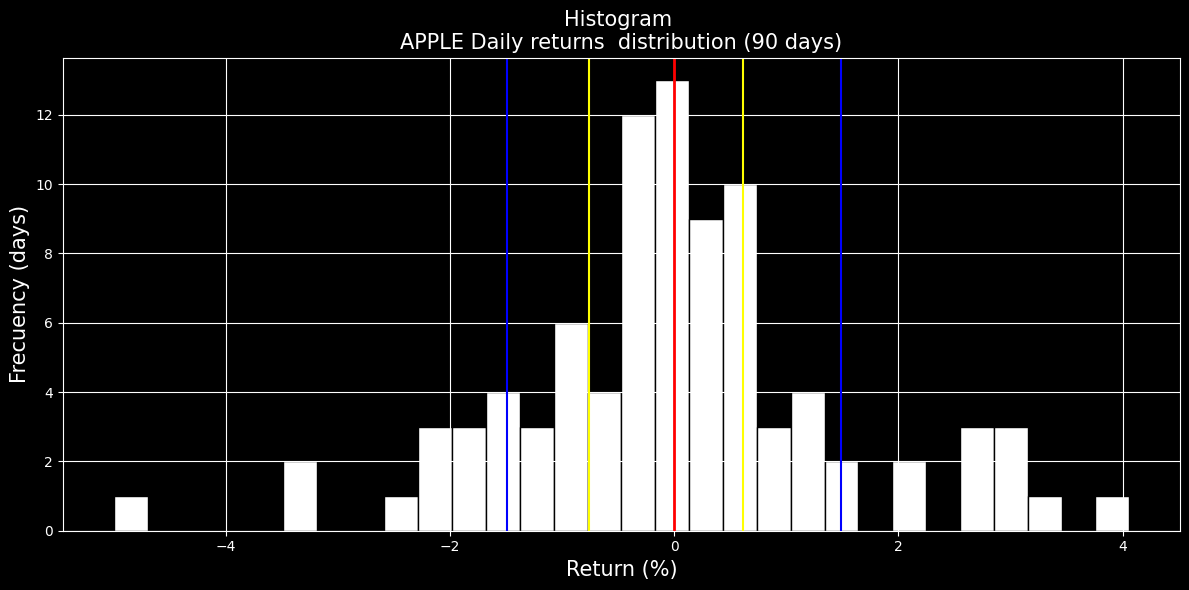

90 days stats
std:    1.487%
skew:  -0.070%
kurt:   1.422%
p25:   -0.757%
p75:    0.612%


In [14]:
std_90 = df_apple['Return'].tail(90).std()
skew_90 = df_apple['Return'].tail(90).skew()
kurt_90 = df_apple['Return'].tail(90).kurt()
p25_90 = df_apple['Return'].tail(90).quantile(0.25)
p75_90 = df_apple['Return'].tail(90).quantile(0.75)

plt.figure(figsize=(12, 6))
plt.hist(df_apple['Return'].tail(90), bins=30, color='white', edgecolor='black')
plt.style.use('dark_background')

plt.axvline(0, color='red', linestyle='-', linewidth=2) # linea visual para el 0
plt.axvline(std_90, color='blue', linestyle='-', linewidth=1.5) # std
plt.axvline(-std_90, color='blue', linestyle='-', linewidth=1.5) # -std
plt.axvline(p25_90, color='yellow', linestyle='-', linewidth=1.5) # percentil 25
plt.axvline(p75_90, color='yellow', linestyle='-', linewidth=1.5) # percentile 75

plt.title('Histogram \nAPPLE Daily returns  distribution (90 days)', fontsize=15)
plt.xlabel('Return (%)', fontsize=15)
plt.ylabel('Frecuency (days)', fontsize=15)
plt.tight_layout()
plt.grid(True)
plt.show()

print('90 days stats')
print(f'std:   {std_90: .3f}%')
print(f'skew:  {skew_90: .3f}%')
print(f'kurt:  {kurt_90: .3f}%')
print(f'p25:   {p25_90: .3f}%')
print(f'p75:   {p75_90: .3f}%')

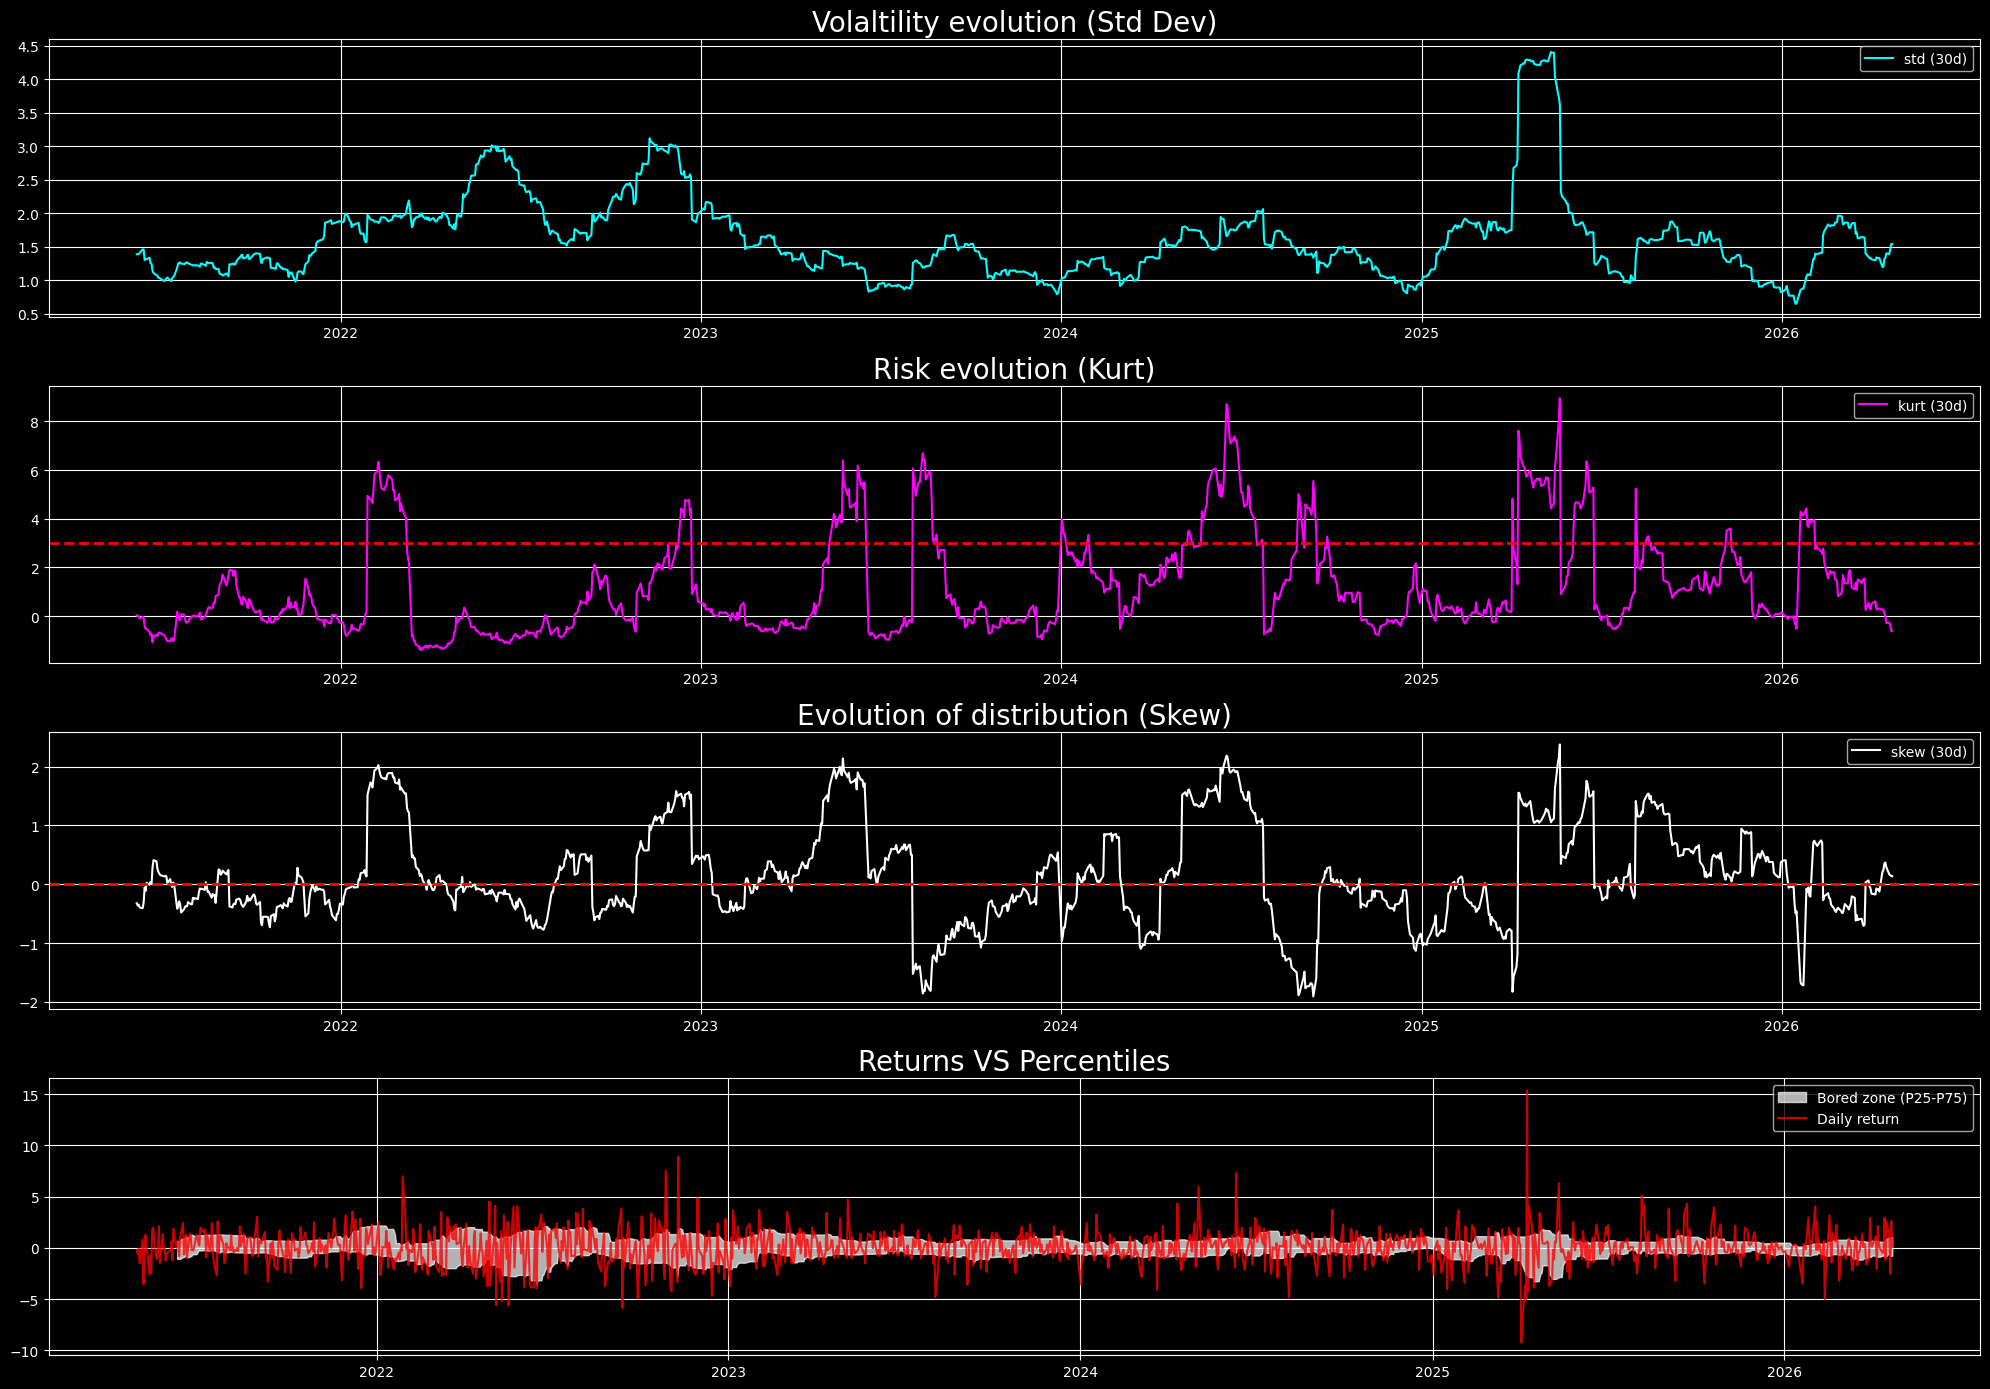

In [15]:
# rolling statistics
rolling_std = df_apple['Return'].rolling(30).std()
rolling_kurt = df_apple['Return'].rolling(30).kurt()
rolling_skew = df_apple['Return'].rolling(30).skew()
rolling_p25 = df_apple['Return'].rolling(30).quantile(0.25)
rolling_p75 = df_apple['Return'].rolling(30).quantile(0.75)

# graficamos
plt.figure(figsize=(20, 14))

plt.subplot(4, 1, 1)
plt.plot(rolling_std, color='cyan', label='std (30d)') # std
plt.title('Volaltility evolution (Std Dev)', fontsize=20)
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(rolling_kurt, color='magenta', label='kurt (30d)') # kurt
plt.axhline(3, color='red', linestyle='--', alpha=1, linewidth=2)
plt.title('Risk evolution (Kurt)', fontsize=20)
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(rolling_skew, color='white', label='skew (30d)') # skew
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Evolution of distribution (Skew)', fontsize=20)
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 4)
plt.fill_between(df_apple.index, rolling_p25, rolling_p75, color='white', alpha=0.7, label='Bored zone (P25-P75)') # percentiles
plt.plot(df_apple['Return'], color='red', alpha=0.8, label='Daily return')
plt.title('Returns VS Percentiles', fontsize=20)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

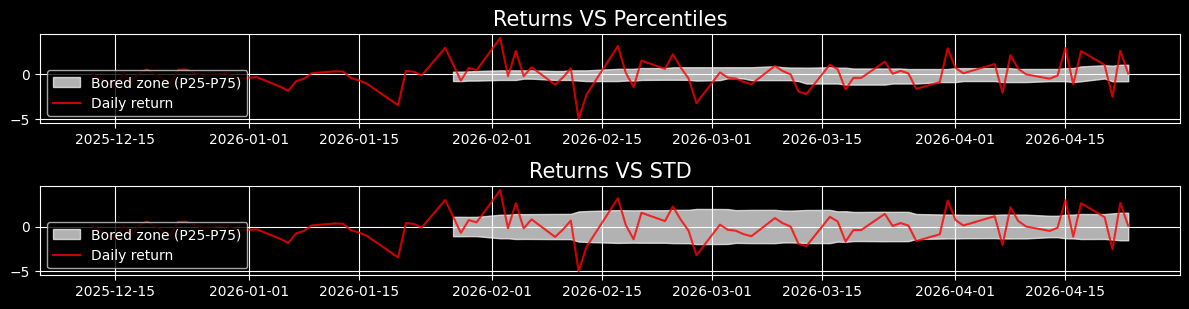

In [16]:
rolling_p25_90 = df_apple['Return'].tail(90).rolling(30).quantile(0.25)
rolling_p75_90 = df_apple['Return'].tail(90).rolling(30).quantile(0.75)
last_90 = df_apple.tail(90)

rolling_std_90 = df_apple['Return'].tail(90).rolling(30).std()


plt.figure(figsize=(12, 6))
plt.subplot(4, 1, 1)
plt.fill_between(last_90.index, rolling_p25_90, rolling_p75_90, color='white', alpha=0.7, label='Bored zone (P25-P75)') # percentiles
plt.plot(last_90['Return'] , color='red', alpha=0.8, label='Daily return')
plt.title('Returns VS Percentiles', fontsize=15)
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.fill_between(last_90.index, rolling_std_90, -rolling_std_90, color='white', alpha=0.7, label='Bored zone (P25-P75)') # std
plt.plot(last_90['Return'] , color='red', alpha=0.8, label='Daily return')
plt.title('Returns VS STD', fontsize=15)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
rolling_p25_90 = rolling_p25_90.reindex(df_apple.index)
rolling_p75_90 = rolling_p75_90.reindex(df_apple.index)

# signal
df_apple['Signal_percentil'] =  (df_apple['Close'] < rolling_p25_90) | (df_apple['Close'] > rolling_p75_90)
df_apple['Signal'] = df_apple['Signal_percentil']

# cantidad de signals
signal_count = df_apple['Signal'].sum()

# probabilidad de que se active
signal_probability = (signal_count / len(df_apple)) * 100

# mover un lugar hacia atras
df_apple['Tomorrow_return'] = df_apple['Return'].shift(-1)
df_apple.dropna(inplace=True)

# ver dias de signal
only_signals = df_apple[df_apple['Signal'] == True]

# promedio dia despues signal
post_signal_mean = only_signals['Tomorrow_return'].dropna().mean()

# promedio diario normal
normal_mean = df_apple['Return'].dropna().mean()

# retorno minimo y maximo
max = df_apple['Tomorrow_return'].max()
min = df_apple['Tomorrow_return'].min()

# cantidad de ganadoras
winners = (only_signals['Tomorrow_return'] > 0).sum()

# win rate
win_rate = (winners / len(only_signals)) * 100

# promedio ganancias, promedio perdidas
avg_earnings = only_signals[only_signals['Tomorrow_return'] > 0]['Tomorrow_return'].mean()
avg_losses = only_signals[only_signals['Tomorrow_return'] < 0]['Tomorrow_return'].abs().mean()

# expectancy
expectancy = (avg_earnings * 0.5) / (avg_losses * 0.5)

print(f'Signal count:      {signal_count}')
print(f'Probability:      {signal_probability: .3f}%')
print(f'Post signal mean: {post_signal_mean: .3f}%')
print(f'Normal mean:      {normal_mean: .3f}%')
print(f'Minimun return:   {min: .3f}%')
print(f'Maximun return:   {max: .3f}%')
print(f'Winning times:     {winners}')
print(f'Win rate:         {win_rate: .3f}%')
print(f'Average earnings: {avg_earnings: .3f}%')
print(f'Average losses:   {avg_losses: .3f}%')
print(f'Expectancy:       {expectancy: .3f}%')

Signal count:      61
Probability:       4.864%
Post signal mean:  0.110%
Normal mean:       0.073%
Minimun return:   -9.246%
Maximun return:    15.329%
Winning times:     32
Win rate:          53.333%
Average earnings:  1.245%
Average losses:    1.187%
Expectancy:        1.049%
